# PhishGuard Live — Exploratory Data Analysis

Dataset built from real, live-collected data:
- **Phishing domains** — OpenPhish feed (updated ~every 6h)
- **Legit domains** — random sample from the Tranco top-1M list

Each domain was converted into numeric features (`src/features/extractor.py`):
domain length, digit/hyphen counts, brand-name similarity (Levenshtein),
suspicious TLD flag, and phishing-keyword count.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/dataset.csv")
df.head()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords,domain,label
0,20,0,0,0.3200,0,0,aakrutisolutions.com,legit
1,18,0,0,0.3333,0,0,delhiescortsncr.in,legit
2,13,0,0,0.3333,0,0,alibaba.co.uk,legit
3,9,0,0,0.0000,0,0,kh.edu.tw,legit
4,14,0,0,0.4286,0,0,layworld.co.jp,legit


## 1. Data overview

Checking dataset size, column types, and missing values before any analysis.

In [2]:
print(df.shape)
df.info()
df.isna().sum()
df.describe()

(2265, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   length          2265 non-null   int64  
 1   digits          2265 non-null   int64  
 2   hyphens         2265 non-null   int64  
 3   brand_sim       2265 non-null   float64
 4   suspicious_tld  2265 non-null   int64  
 5   keywords        2265 non-null   int64  
 6   domain          2265 non-null   str    
 7   label           2265 non-null   str    
dtypes: float64(1), int64(5), str(2)
memory usage: 141.7 KB


,length,digits,hyphens,brand_sim,suspicious_tld,keywords
count,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000
mean,15.320530,0.441501,0.243267,0.357118,0.016777,0.010155
std,6.808307,1.310885,0.684560,0.104383,0.128463,0.100279
min,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000,0.307700,0.000000,0.000000
50%,14.000000,0.000000,0.000000,0.363600,0.000000,0.000000
75%,18.000000,0.000000,0.000000,0.421100,0.000000,0.000000
max,61.000000,15.000000,5.000000,0.782600,1.000000,1.000000


In [3]:
df["label"].value_counts()

label
legit       2000
phishing     265
Name: count, dtype: int64

## 2. Class balance

Real-world phishing datasets are always imbalanced -- confirming that
here matters, since it determines which evaluation metrics make sense
later (accuracy would be misleading).

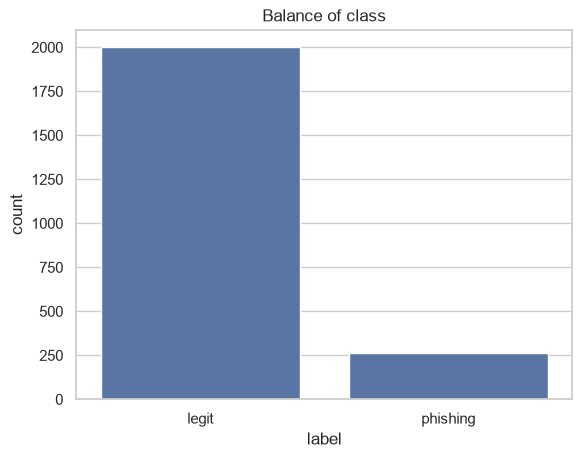

In [4]:
sns.countplot(data=df, x="label")
plt.title("Balance of class")
plt.show()

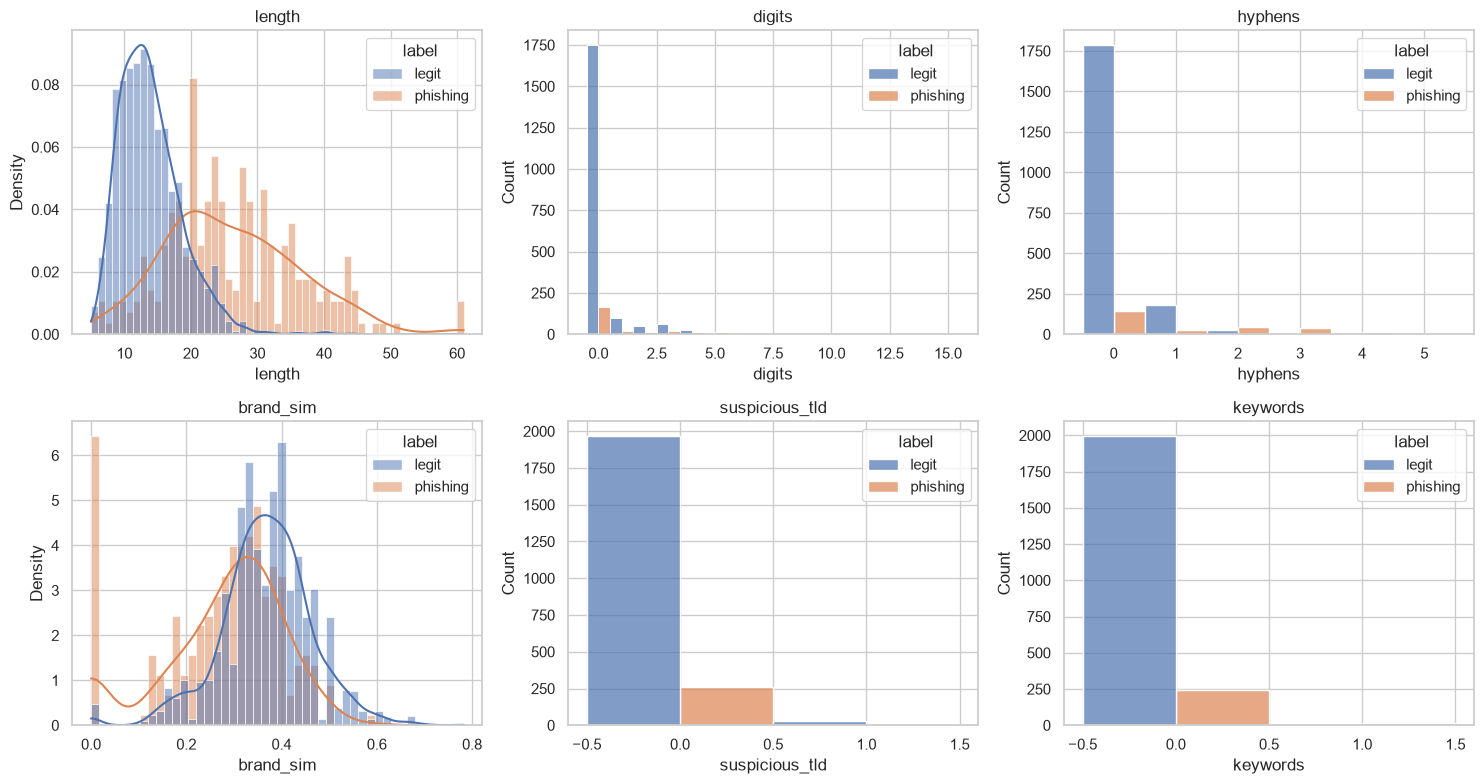

In [19]:
numeric_cols = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
continuous_cols = ["length", "brand_sim"] 

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    if col in continuous_cols:
        sns.histplot(data=df, x=col, hue="label", kde=True, ax=axes[i],
                     stat="density", common_norm=False, alpha=0.5)
    else:
        sns.histplot(data=df, x=col, hue="label", kde=False, ax=axes[i],
                     discrete=True, multiple="dodge", alpha=0.7)
        
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [6]:
df.groupby("label")[numeric_cols].mean()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords
label,,,,,,
legit,13.882500,0.294500,0.128500,0.367622,0.016000,0.002000
phishing,26.173585,1.550943,1.109434,0.277848,0.022642,0.071698


## Feature correlation heatmap

Checking how features relate to each other before moving to PCA and modeling.

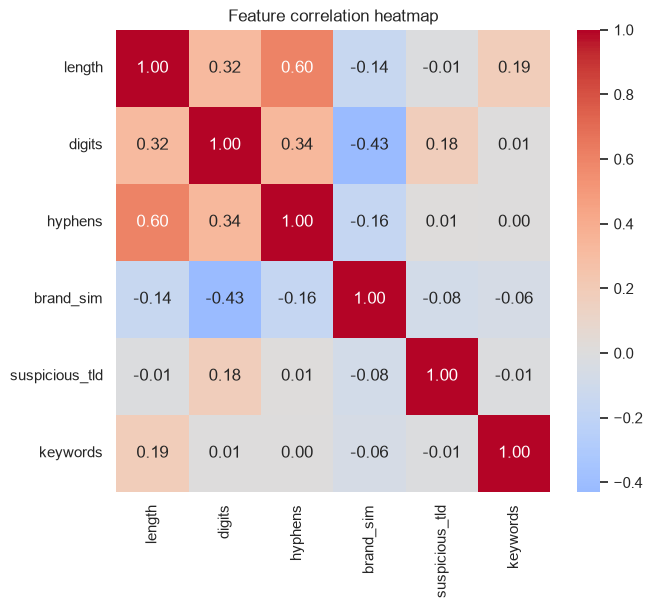

In [7]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

## EDA summary

- Dataset is imbalanced: ~15% phishing, ~85% legit (real-world proportion).
- No missing values across all 2265 rows.
- `brand_sim` and `length` show clearly different distributions between
  classes and look like the strongest individual signals.
- Sparse features (`digits`, `hyphens`, `suspicious_tld`, `keywords`) have
  low frequency in both classes, but noticeably higher averages for
  phishing domains.
- Moderate correlation (0.6) between `length` and `hyphens` -- expected,
  since longer domains have more room for hyphens. Not high enough to be
  a multicollinearity concern.
- Next steps: PCA to visualize class separability in 2D, then train and
  compare several classification models.

## 6. PCA — dimensionality reduction

Projecting all 6 features into 2 dimensions to visually check whether
phishing and legit domains form separable clusters in feature space.
This is a sanity check before training any model.

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [9]:
X = df[numeric_cols].values
y = df["label"].values

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [12]:
print(pca.explained_variance_ratio_)

[0.34065725 0.1949672 ]


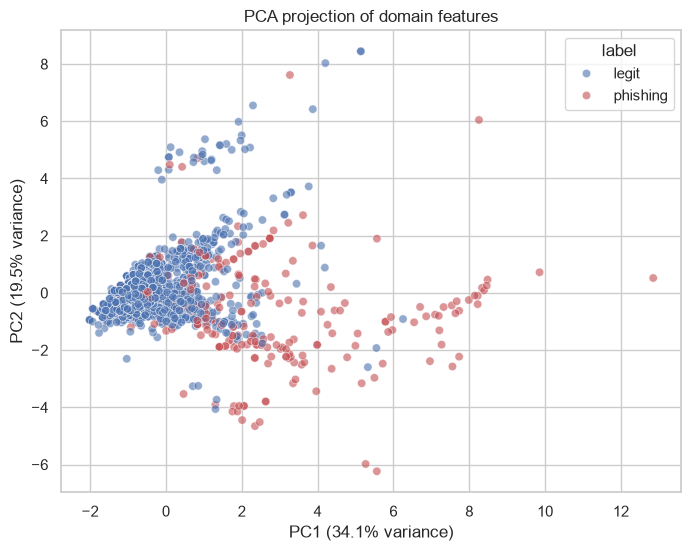

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["label"], alpha=0.6,
                 palette={"legit": "#4C72B0", "phishing": "#C44E52"})
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection of domain features")
plt.show()


## PCA conclusion

The two classes show partial separation: phishing domains tend to spread
toward higher PC1 values (longer names, higher brand similarity, more
keywords), while legit domains form a dense cluster near the origin.
There's significant overlap in the middle region, meaning the classes
aren't perfectly linearly separable in 2D -- this suggests non-linear
models (e.g. Random Forest) may outperform simpler linear ones later.

Note: PC1+PC2 only explain ~53.5% of total variance, so this 2D view
is a simplification -- the actual classifier will use all 6 features.